Creacion de una imagen

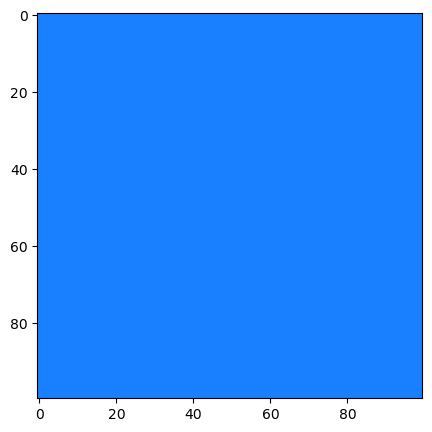

In [10]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

plt.rcParams['figure.figsize']=[10,5]
tamaño_img = 100
R = np.ones((tamaño_img,tamaño_img)) * 25
G = np.ones((tamaño_img,tamaño_img)) * 128
B = np.ones((tamaño_img,tamaño_img)) * 255

imagen = np.dstack((R,G,B))
imagen = np.array(imagen,dtype=int)

plt.figure()
plt.imshow(imagen)
plt.show()

Escala de grises / Profundidad de color

profundida del color: uint8
profundida del color nueva: uint16


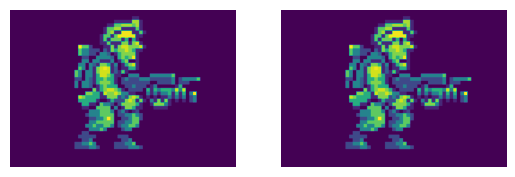

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = cv2.imread('imagenPNG.png',cv2.IMREAD_GRAYSCALE)
img_inicial = imagen.dtype #valor de prufundidad de color inicial
print(f'profundida del color: {img_inicial}')

img_16bit = np.uint16(imagen)
img_nueva = img_16bit.dtype
print(f'profundida del color nueva: {img_nueva}')

plt.subplot(1,2,1)
plt.imshow(imagen)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_16bit)
plt.axis('off')


plt.show()
plt.imsave('img16bit.jpg',img_16bit)

RGB a HSV

Text(0.5, 1.0, 'canal V')

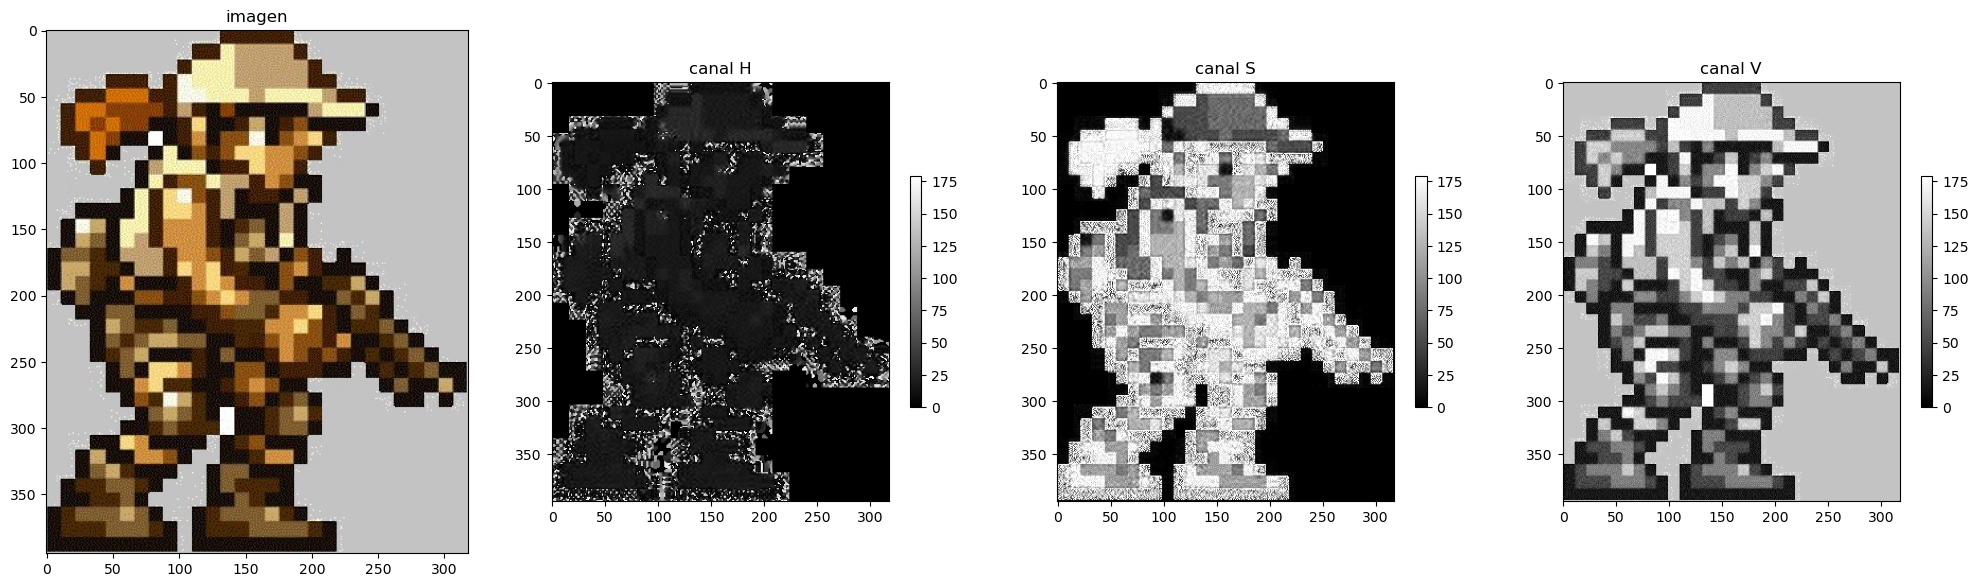

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1,4,figsize=(25,10))
img_bgr=cv2.imread('imag1JPEG.jpg')
img_rgb=cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)

axs[0].imshow(img_rgb)
axs[0].set_title('imagen')

fig_img1 = axs[1].imshow(hsv[...,0],cmap='gray',vmin=0,vmax=179)
fig.colorbar(fig_img1,ax=axs[1],shrink=0.3)
axs[1].set_title('canal H')

fig_img2 = axs[2].imshow(hsv[...,1],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img1,ax=axs[2],shrink=0.3)
axs[2].set_title('canal S')

fig_img3 = axs[3].imshow(hsv[...,2],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img1,ax=axs[3],shrink=0.3)
axs[3].set_title('canal V')

RGB 4 cuadrantes

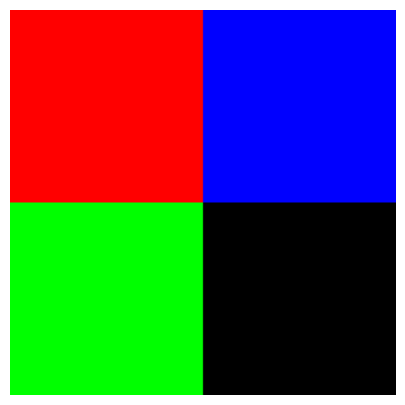

In [34]:
import matplotlib.pyplot as plt
import numpy as np

tamaño_img = 100
R = np.ones((tamaño_img,tamaño_img))
G = np.ones((tamaño_img,tamaño_img))
B = np.ones((tamaño_img,tamaño_img))

rojo = np.dstack((R * 255,G * 0,B* 0))       

verde = np.dstack((R * 0, G * 255,B * 0))      

azul = np.dstack((R * 0,G * 0,B * 255))  

negro = np.dstack((R * 0,G * 0,B * 0))     

superior = np.hstack((rojo, azul))
inferior = np.hstack((verde, negro))
imagen = np.vstack((superior, inferior))

plt.imshow(imagen.astype(int))
plt.axis('off')
plt.show()


HVS 2

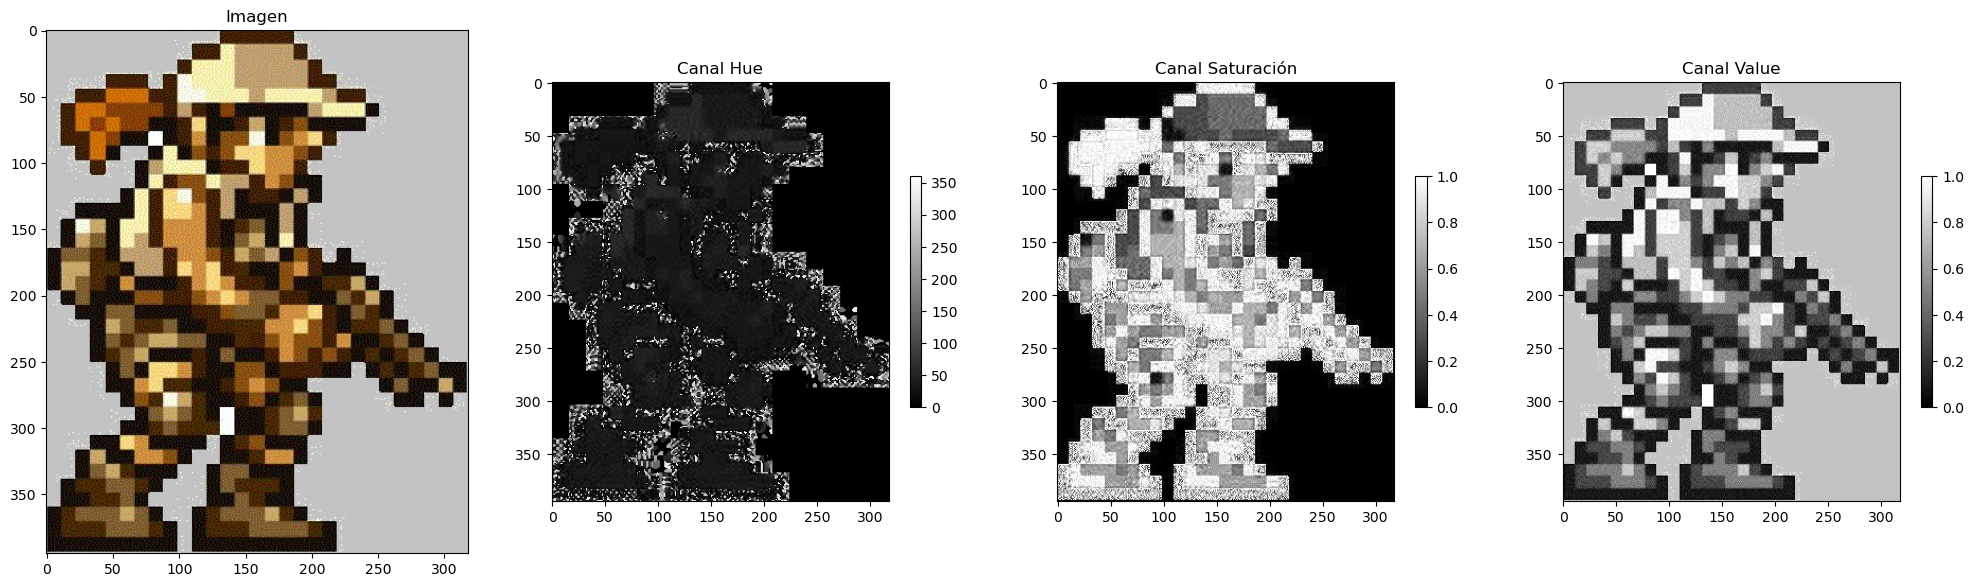

In [3]:
import numpy as np
Imagen = cv2.imread('imag1JPEG.jpg')
img= cv2.cvtColor(Imagen, cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        bol_ind = new_img[...,0] < 0
        new_img[bol_ind,0]   =  new_img[bol_ind,0] + 360
    return new_img 

hsv_img =  RGB2HSV(img) 
fig, axs = plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('Imagen')
fig_img = axs[1].imshow(hsv_img[...,0],cmap='gray',vmin=0,vmax=360)
fig.colorbar(fig_img, ax=axs[1],shrink=0.3)
axs[1].set_title('Canal Hue')
fig_img = axs[2].imshow(hsv_img[...,1],cmap='gray',vmin=0,vmax=1)
fig.colorbar(fig_img, ax=axs[2],shrink=0.3)
axs[2].set_title('Canal Saturación')
fig_img = axs[3].imshow(hsv_img[...,2],cmap='gray',vmin=0,vmax=1)
fig.colorbar(fig_img, ax=axs[3],shrink=0.3)
axs[3].set_title('Canal Value');

Text(0.5, 1.0, 'Canal Azul')

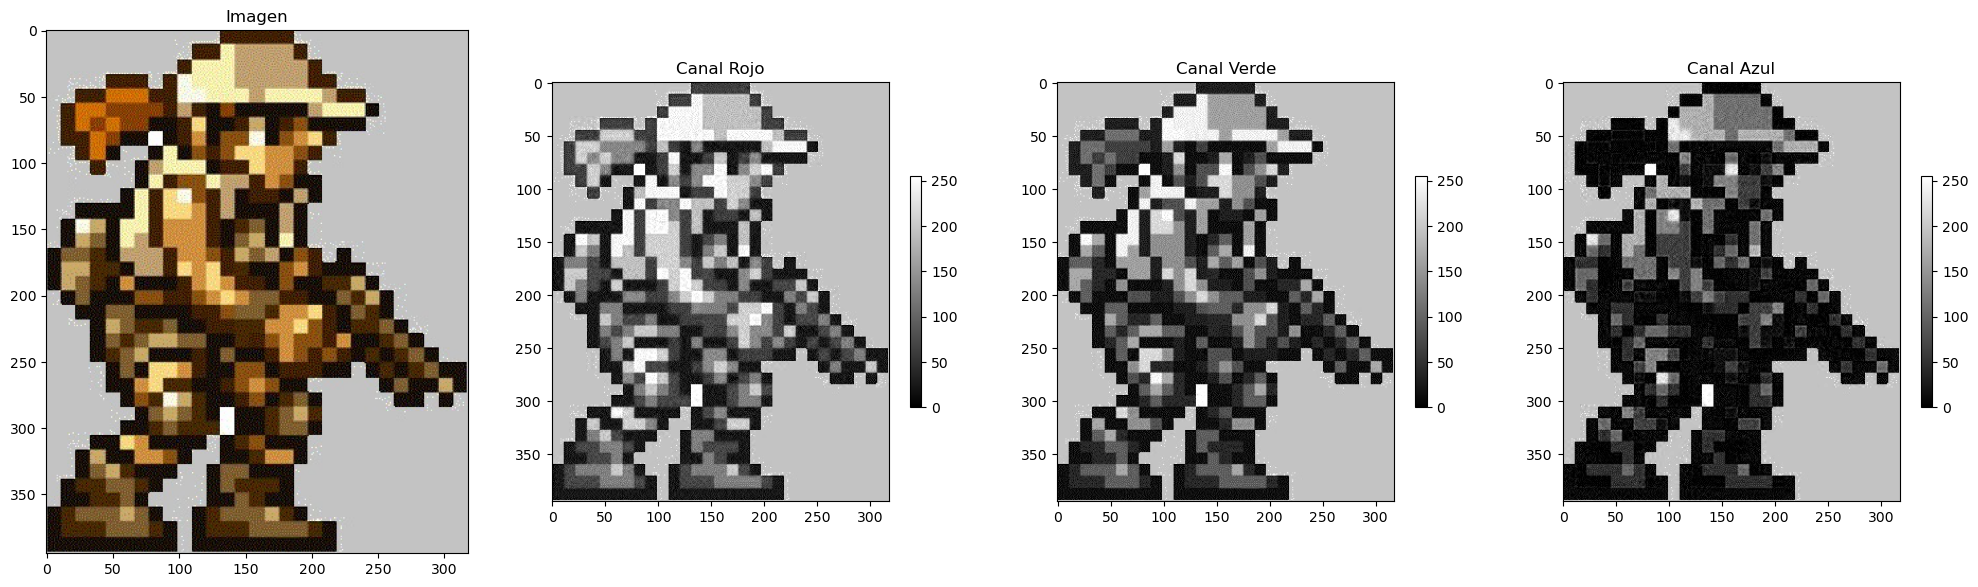

In [4]:
def HSV2RGB(img):
    new_img = np.zeros_like(img)
    
    C = img[...,2]*img[...,1]
    X = C*(1-abs((img[...,0]/60)%2-1))
    m = img[...,2]-C

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            h = img[i,j,0]
            if 0 <= h and h < 60:
                new_img[i,j] = C[i,j],X[i,j],0
            elif 60 <= h and h < 120:
                new_img[i,j] = X[i,j],C[i,j],0
            elif 120 <= h and h < 180:
                new_img[i,j] = 0,C[i,j],X[i,j]
            elif 180 <= h and h < 240:
                new_img[i,j] = 0,X[i,j],C[i,j]
            elif 240 <= h and h < 300:
                new_img[i,j] = X[i,j],0,C[i,j]
            elif 300 <= h and h < 360:
                new_img[i,j] = C[i,j],0,X[i,j]
    new_img[...,0] = (new_img[...,0]+m)*255
    new_img[...,1] = (new_img[...,1]+m)*255
    new_img[...,2] = (new_img[...,2]+m)*255
    new_img = new_img.astype(int)
    return new_img 
rgb_img =   HSV2RGB(hsv_img) 
fig, axs = plt.subplots(1,4,figsize=(25,10))

axs[0].imshow(img)
axs[0].set_title('Imagen')


fig_img = axs[1].imshow(rgb_img[...,0],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img, ax=axs[1],shrink=0.3)
axs[1].set_title('Canal Rojo')


fig_img = axs[2].imshow(rgb_img[...,1],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img, ax=axs[2],shrink=0.3)
axs[2].set_title('Canal Verde')


fig_img = axs[3].imshow(rgb_img[...,2],cmap='gray',vmin=0,vmax=255)
fig.colorbar(fig_img, ax=axs[3],shrink=0.3)
axs[3].set_title('Canal Azul')

HSV a RGB

Text(0.5, 1.0, 'imagen original')

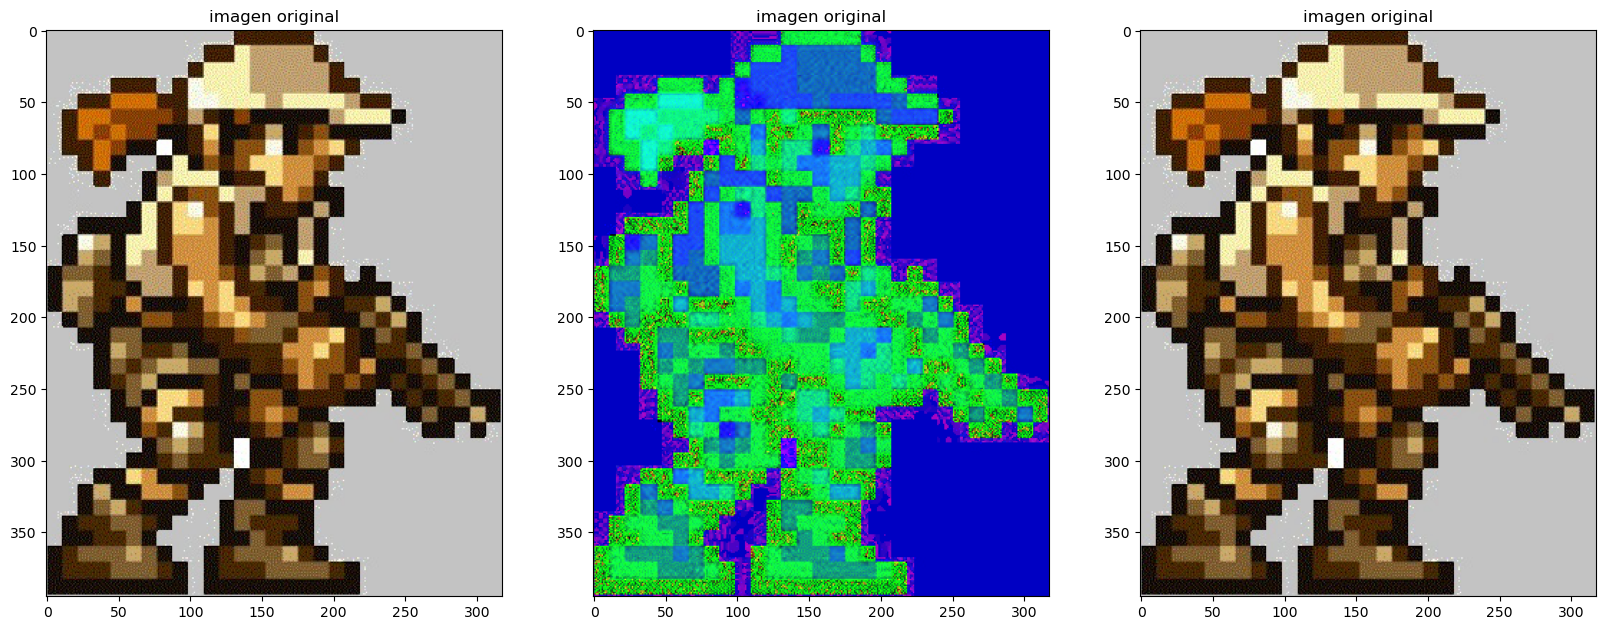

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_rgb = cv2.cvtColor(cv2.imread('imag1JPEG.jpg',cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)
img_rgb2 = cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)

fig,axs = plt.subplots(1,3,figsize=[20,10])

axs[0].imshow(img_rgb)
axs[0].set_title('imagen original')

axs[1].imshow(img_hsv)
axs[1].set_title('imagen original')

axs[2].imshow(img_rgb2)
axs[2].set_title('imagen original')

(-0.5, 317.5, 394.5, -0.5)

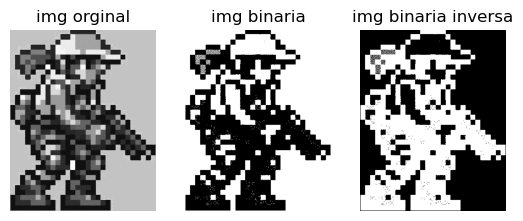

In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen = cv2.imread('imag1JPEG.jpg',0) 
_, umbralBinario = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY)
_, umbralBinarioInverso = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)


plt.subplot(1,3,1)
plt.imshow(imagen, cmap='gray')
plt.title('img orginal')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(umbralBinario, cmap='gray')
plt.title('img binaria')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(umbralBinarioInverso, cmap='gray')
plt.title('img binaria inversa')
plt.axis('off')
